<a href="https://colab.research.google.com/github/paucp1/algoritmos_optimizacion/blob/main/Seminario_Algoritmos_PauCarbo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de optimización - Seminario<br>
Nombre y Apellidos:   Pau Carbó Pascual<br>
Url: https://github.com/paucp1/algoritmos_optimizacion/blob/main/Seminario_Algoritmos_PauCarbo.ipynb<br>
Problema:
>2. Organizar los horarios de partidos de La Liga<br>

<b>Descripción del problema:</b>

Desde la La Liga de fútbol profesional se pretende organizar los horarios de los partidos de liga de cada jornada. Se conocen algunos datos que nos deben llevar a diseñar un algoritmo que realice la asignación de los partidos a los horarios de forma que <b>maximice la audiencia</b>.

Los horarios disponibles se conocen a priori y son los siguientes: <br>
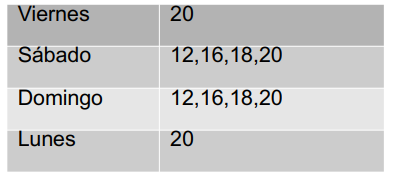

En primer lugar se clasifican los equipos en tres categorías según el numero de
seguidores( que tiene relación directa con la audiencia). Hay <b>3 equipos</b> en la <b>categoría A</b>, <b>11 equipos</b> de <b>categoría B</b> y <b>6 equipos</b> de <b>categoría C</b>.

Se conoce estadísticamente la audiencia que genera cada partido según los equipos que se enfrentan y en horario de sábado a las 20h (el mejor en todos los casos) <br>

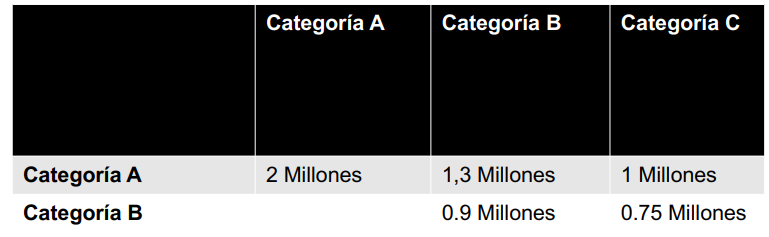

Si el horario del partido no se realiza a las 20 horas del sábado se sabe que se reduce según los coeficientes de la siguiente tabla.

Debemos asignar obligatoriamente siempre un partido el viernes y un partido el lunes. <br>

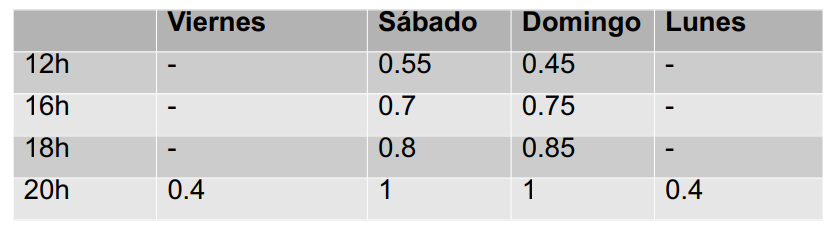

Es posible la coincidencia de horarios pero en este caso la audiencia de cada partido se verá afectada y se estima que se reduce en porcentaje según la siguiente tabla dependiendo del número de coincidencias: <br>

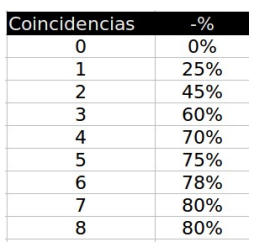

(*) La respuesta es obligatoria





                                        

<b>(*)¿Cuantas posibilidades hay sin tener en cuenta las restricciones?<br>



¿Cuantas posibilidades hay teniendo en cuenta todas las restricciones.</b>





Tenemos:

*   10 partidos (ya determinados por el sorteo de la jornada — no hay que decidir emparejamientos, solo horarios)
*   10 horarios disponibles: Viernes-20h, Sábado-{12,16,18,20h}, Domingo-{12,16,18,20h}, Lunes-20h

Como ya hemos visto que se permite la coincidencia de horarios (varios partidos en el mismo slot, penalizando audiencia), el problema de asignación no es una permutación (biyección 1 a 1), sino una función de partidos → horarios: cada partido se asigna a uno de los 10 horarios, pero varios partidos pueden compartir horario.<br>

<b>Sin restricciones</b>

Cada uno de los 10 partidos puede colocarse libremente en cualquiera de los 10 horarios, de forma independiente:

10<sup>10</sup>=10.000.000.000 posibilidades

<b>Con restricciones</b>

La única restricción dada es: exactamente un partido el viernes a las 20h y exactamente un partido el lunes a las 20h (los otros 8 partidos se reparten libremente, con posible coincidencia, entre los 8 horarios restantes: sábado 12/16/18/20h y domingo 12/16/18/20h).

* Elegir qué partido va el viernes: 10 opciones
* Elegir qué partido va el lunes (de los 9 restantes): 9 opciones
* Los 8 partidos restantes, cada uno libremente en 8 horarios posibles: 8<sup>8</sup>

10×9×8<sup>8</sup>=1.509.949.440 posibilidades



In [1]:
from math import comb

# Sin restricciones
n_partidos = 10
n_horarios = 10

posibilidades_sin_restricciones = n_horarios ** n_partidos
print(f"Posibilidades sin restricciones: {posibilidades_sin_restricciones:,}")

# Con restricciones (1 partido obligatorio el viernes, 1 obligatorio el lunes)
# Viernes: elegir 1 de los 10 partidos
opciones_viernes = n_partidos

# Lunes: elegir 1 de los 9 partidos restantes
opciones_lunes = n_partidos - 1

# Los 8 partidos restantes se asignan libremente entre los 8 horarios restantes
# (sábado 12,16,18,20h y domingo 12,16,18,20h), permitiendo coincidencias
n_horarios_restantes = n_horarios - 2  # 8
n_partidos_restantes = n_partidos - 2  # 8

posibilidades_con_restricciones = (
    opciones_viernes * opciones_lunes * (n_horarios_restantes ** n_partidos_restantes)
)
print(f"Posibilidades con restricciones: {posibilidades_con_restricciones:,}")

Posibilidades sin restricciones: 10,000,000,000
Posibilidades con restricciones: 1,509,949,440


*Modelo para el espacio de soluciones*<br>
**(*) ¿Cual es la estructura de datos que mejor se adapta al problema? Argumentalo.(Es posible que hayas elegido una al principio y veas la necesidad de cambiar, arguentalo)**


La estructura que mejor se adapta es un vector (array) de longitud 10, donde:

* El índice
𝑖
i representa el partido
𝑖
i (fijo, ya viene dado por el sorteo de la jornada)
* El valor solucion[i] ∈ {0, ..., 9} representa el horario asignado a ese partido (con repetición permitida)

Esto se complementa con dos estructuras auxiliares fijas (no cambian entre soluciones, son los datos del problema):

* Lista de partidos, cada uno con (equipo_local, equipo_visitante, categoría_local, categoría_visitante, audiencia_base)
* Lista de horarios, cada uno con (día, hora, coeficiente_reductor)

In [2]:
from collections import Counter, namedtuple

# Estructuras de datos fijas del problema
Partido = namedtuple("Partido", ["local", "visitante", "cat_local", "cat_visitante", "audiencia_base"])
Horario = namedtuple("Horario", ["dia", "hora", "coeficiente"])

horarios = [
    Horario("Viernes", 20, 0.40),
    Horario("Sabado", 12, 0.55),
    Horario("Sabado", 16, 0.70),
    Horario("Sabado", 18, 0.80),
    Horario("Sabado", 20, 1.00),
    Horario("Domingo", 12, 0.45),
    Horario("Domingo", 16, 0.75),
    Horario("Domingo", 18, 0.85),
    Horario("Domingo", 20, 1.00),
    Horario("Lunes", 20, 0.40),
]

# Representación de una solución candidata
# Vector de longitud 10 (uno por partido), valor = índice de horario asignado (0-9)
# Ejemplo de solución (aleatoria, solo ilustrativa):
solucion = [0, 4, 4, 9, 1, 2, 3, 5, 6, 7]

# Para calcular las coincidencias por horario, basta contar ocurrencias:
coincidencias_por_horario = Counter(solucion)
print(coincidencias_por_horario)

Counter({4: 2, 0: 1, 9: 1, 1: 1, 2: 1, 3: 1, 5: 1, 6: 1, 7: 1})


Esta estructura (vector de enteros de longitud fija, con repetición permitida) es la más adecuada porque:

1. Se ajusta al modelo real del problema: permite representar de forma natural que varios partidos compartan horario, algo que una permutación no permite.
2. Facilita el cálculo de la función objetivo: contar coincidencias por horario es trivial con Counter (o un array de tamaño 10 con contadores), en O(n).
3. Es idónea para metaheurísticas (búsqueda local, algoritmos genéticos, recocido simulado):

- Mutación: cambiar el horario de un solo partido es tan simple como modificar una posición del vector (operación O(1)).
- Cruce en algoritmos genéticos: al no ser una permutación, se pueden usar operadores de cruce estándar (un punto, uniforme, etc.) sin necesidad de reparaciones complejas como las que exigen las permutaciones (evitar duplicados de genes).
- Codificación compacta: 10 enteros pequeños (0-9), fácil de vectorizar con NumPy para evaluar poblaciones enteras de golpe.
4. Las restricciones "duras" son fáciles de imponer o reparar: fijar solucion[0] = 0 (viernes) y solucion[i] = 9 (lunes) para algún partido, o penalizar/reparar soluciones que no cumplan que viernes y lunes tengan exactamente un partido.

Por eso, aunque la intuición inicial (por la simetría 10 partidos/10 horarios) apunta a una permutación, la posibilidad de coincidencias obliga a cambiar a un vector de asignación con repetición, que es la estructura que finalmente usaremos como base para el resto del proyecto (generación de vecinos, cruces, mutaciones, etc.).

*Según el modelo para el espacio de soluciones*<br>
**(*)¿Cual es la función objetivo?**

**(*)¿Es un problema de maximización o minimización?**

Es un problema de maximización: queremos maximizar la audiencia total generada por los 10 partidos de la jornada. La Liga busca el reparto de horarios que atraiga al mayor número de espectadores posible en conjunto.

**Función objetivo**

Notación:

* P={1,...,10}: conjunto de partidos de la jornada
* H={1,...,10}: conjunto de horarios disponibles
* 𝑥<sub>𝑝</sub> ∈ 𝐻: horario asignado al partido 𝑝 (variable de decisión → nuestro vector solucion)
* 𝑎<sub>𝑝</sub>: audiencia base del partido 𝑝 (según las categorías de los equipos que se enfrentan, en el horario de referencia sábado 20h)
* 𝑐<sub>ℎ</sub>: coeficiente reductor del horario ℎ (tabla día/hora)
* 𝑛<sub>ℎ</sub>(𝑥): número de partidos asignados al horario ℎ en la solución 𝑥, es decir 𝑛<sub>ℎ</sub>(𝑥)=∣{𝑝∈𝑃:𝑥𝑝=ℎ}∣
* 𝑟(𝑘): función de reducción por coincidencias, según la tabla (0→0%, 1→25%, 2→45%, ...), donde 𝑘 = nº de otros partidos coincidiendo (es decir 𝑘=𝑛<sub>ℎ</sub>(𝑥)−1)

Audiencia real de un partido 𝑝 asignado al horario ℎ =𝑥<sub>𝑝</sub>:

𝐴<sub>𝑝</sub>(𝑥) = 𝑎<sub>𝑝</sub> ⋅ 𝑐<sub>𝑥<sub>𝑝</sub></sub> ⋅ (1 − 𝑟(𝑛<sub>𝑥<sub>𝑝</sub></sub>(𝑥) − 1))

Función objetivo (a maximizar):

max⁡ 𝑥 𝑍(𝑥)=∑<sub>𝑝=1</sub><sup>10</sup>𝑎<sub>𝑝</sub> ⋅ 𝑐<sub>𝑥<sub>𝑝</sub></sub> ⋅ (1 − 𝑟(𝑛<sub>𝑥<sub>𝑝</sub></sub>(𝑥) − 1))

sujeto a las restricciones (exactamente un partido en viernes-20h, exactamente uno en lunes-20h, y cada partido asignado a un único horario).

In [12]:
# Tabla de reducción por coincidencias (k = nº de OTROS partidos en el mismo horario)
reduccion_coincidencias = {
    0: 0.00,
    1: 0.25,
    2: 0.45,
    3: 0.60,
    4: 0.70,
    5: 0.75,
    6: 0.78,
    7: 0.80,
    8: 0.80,
}

def funcion_objetivo(solucion, audiencias_base, horarios):
    """
    Calcula la audiencia total (a maximizar) de una jornada.

    solucion: lista de longitud 10, solucion[p] = índice de horario (0-9) asignado al partido p
    audiencias_base: lista de longitud 10, audiencia base a_p de cada partido
    horarios: lista de Horario(dia, hora, coeficiente)
    """
    # Contar cuántos partidos hay en cada horario
    n_por_horario = Counter(solucion)

    audiencia_total = 0.0
    for p, h in enumerate(solucion):
        a_p = audiencias_base[p]
        c_h = horarios[h].coeficiente
        k = n_por_horario[h] - 1  # nº de OTROS partidos coincidiendo
        reduccion = reduccion_coincidencias[k]
        audiencia_total += a_p * c_h * (1 - reduccion)

    return audiencia_total

# Ejemplo de uso
audiencias_base_ejemplo = [2.0, 1.3, 1.0, 0.9, 0.75, 0.47, 1.3, 1.0, 0.9, 0.75]
solucion_ejemplo = [0, 4, 4, 9, 1, 2, 3, 5, 6, 7]

Z = funcion_objetivo(solucion_ejemplo, audiencias_base_ejemplo, horarios)
print(f"Audiencia total estimada: {Z:.3f} millones")

Audiencia total estimada: 6.429 millones


**Diseña un algoritmo para resolver el problema por fuerza bruta**

Vamos a generar todas las asignaciones posibles de partidos a horarios que cumplan las restricciones obligatorias (un partido en viernes-20h, un partido en lunes-20h), evaluar la función objetivo en cada una, y quedarnos con la de mayor audiencia.



In [ ]:
#Pseudocódigo
mejor_solucion ← ninguna
mejor_valor ← -infinito

para cada partido_viernes en P:                          # 10 opciones
    para cada partido_lunes en P \ {partido_viernes}:     # 9 opciones
        restantes ← P \ {partido_viernes, partido_lunes}  # 8 partidos
        para cada asignación de restantes a los 8 horarios restantes (con repetición):  # 8^8
            construir solución completa x
            valor ← funcion_objetivo(x)
            si valor > mejor_valor:
                mejor_valor ← valor
                mejor_solucion ← x

devolver mejor_solucion, mejor_valor

In [13]:
import itertools
import time

def fuerza_bruta(audiencias_base, horarios, limite_evaluaciones=None):
    """
    Resuelve el problema de asignación de horarios por fuerza bruta.

    Recorre todas las asignaciones factibles (partido -> horario) que cumplen:
      - Exactamente un partido en Viernes-20h (horario índice 0)
      - Exactamente un partido en Lunes-20h (horario índice 9)
      - Los 8 partidos restantes se asignan libremente a los 8 horarios intermedios (1..8),
        permitiendo coincidencias.

    limite_evaluaciones: si se indica, corta la búsqueda tras ese nº de evaluaciones
                         (útil para estimar tiempos sin ejecutar las ~1.500M completas).
    """
    n_partidos = len(audiencias_base)
    partidos = list(range(n_partidos))
    horarios_intermedios = list(range(1, 9))  # índices 1..8 (excluye viernes=0 y lunes=9)

    mejor_valor = float("-inf")
    mejor_solucion = None
    evaluaciones = 0

    for partido_viernes in partidos:
        for partido_lunes in partidos:
            if partido_lunes == partido_viernes:
                continue

            restantes = [p for p in partidos if p not in (partido_viernes, partido_lunes)]

            # Todas las asignaciones posibles (con repetición) de los 8 restantes
            # a los 8 horarios intermedios: 8^8 combinaciones
            for asignacion in itertools.product(horarios_intermedios, repeat=len(restantes)):
                solucion = [None] * n_partidos
                solucion[partido_viernes] = 0   # horario Viernes-20h
                solucion[partido_lunes] = 9     # horario Lunes-20h
                for p, h in zip(restantes, asignacion):
                    solucion[p] = h

                valor = funcion_objetivo(solucion, audiencias_base, horarios)
                evaluaciones += 1

                if valor > mejor_valor:
                    mejor_valor = valor
                    mejor_solucion = solucion.copy()

                if limite_evaluaciones and evaluaciones >= limite_evaluaciones:
                    return mejor_solucion, mejor_valor, evaluaciones

    return mejor_solucion, mejor_valor, evaluaciones


# Prueba con un límite de evaluaciones para estimar el tiempo
inicio = time.time()
sol, val, evals = fuerza_bruta(audiencias_base_ejemplo, horarios, limite_evaluaciones=100_000)
fin = time.time()

tiempo_por_eval = (fin - inicio) / evals
tiempo_total_estimado = tiempo_por_eval * 1_509_949_440

print(f"Evaluaciones realizadas: {evals:,}")
print(f"Tiempo empleado: {fin - inicio:.4f} s")
print(f"Tiempo estimado por evaluación: {tiempo_por_eval*1e6:.3f} µs")
print(f"Tiempo TOTAL estimado para las 1.509.949.440 soluciones: "
      f"{tiempo_total_estimado/3600:.2f} horas")

Evaluaciones realizadas: 100,000
Tiempo empleado: 0.4921 s
Tiempo estimado por evaluación: 4.921 µs
Tiempo TOTAL estimado para las 1.509.949.440 soluciones: 2.06 horas


**Calcula la complejidad del algoritmo por fuerza bruta**

El algoritmo tiene tres niveles de decisión anidados:

1. Elegir el partido del viernes: 𝑛 opciones (siendo 𝑛 = 10 el número de partidos)
2. Elegir el partido del lunes (de los restantes): (𝑛−1) opciones
3. Asignar los (𝑛−2) partidos restantes a los (𝑚−2) horarios intermedios, permitiendo repetición: (𝑚−2)<sup>𝑛−2</sup> opciones (siendo 𝑚=10 el número total de horarios)

Número total de soluciones a evaluar:

𝑇(𝑛,𝑚) = 𝑛 ⋅(𝑛−1)⋅(𝑚−2)<sup>𝑛−2</sup>

Con 𝑛 = 𝑚 = 10:

𝑇(10,10)=10⋅9⋅8<sup>8</sup>=1.509.949.440

Coste por evaluación:

Cada evaluación de la función objetivo requiere:

* Contar las coincidencias por horario: 𝑂(𝑛) (con un Counter/array de tamaño 𝑚)
* Calcular la audiencia de cada partido y sumarla: 𝑂(𝑛)

Por tanto, cada evaluación cuesta 𝑂(𝑛).

Complejidad temporal total:

𝑂(𝑛 ⋅(𝑛−1)⋅(𝑚−2)<sup>𝑛−2</sup> ⋅𝑛) = 𝑂(𝑛<sup>2</sup>⋅(𝑚−2)<sup>𝑛−2</sup>)

Esto es una complejidad exponencial en el número de partidos 𝑛 (con 𝑚 fijo), ya que 𝑛 aparece en el exponente. Es, en concreto, del orden de 𝑂(𝑘<sup>𝑛</sup>) para una constante 𝑘, lo que la clasifica como un problema de complejidad exponencial, propio de la clase de problemas NP-difíciles cuando se buscan óptimos exactos por enumeración.

**(*)Diseña un algoritmo que mejore la complejidad del algortimo por fuerza bruta. Argumenta porque crees que mejora el algoritmo por fuerza bruta**

Antes de lanzarnos a diseñar el algoritmo, merece la pena pararse un momento a pensar en la naturaleza del problema. Tenemos 10 partidos y 10 horarios disponibles, así que la opción más simple —asignar un único partido a cada horario, sin que se solape ninguno— es perfectamente viable: se trata de una biyección, y además cumple sin ningún esfuerzo adicional las restricciones de viernes y lunes.

Esto nos lleva a preguntarnos algo que resulta clave para el diseño del algoritmo: ¿tiene sentido en algún caso provocar deliberadamente una coincidencia de horarios? Para responder, comparamos dos escenarios con dos partidos cualesquiera de audiencias base 𝑎<sub>1</sub> y 𝑎<sub>2</sub>, y dos horarios de coeficientes 𝑐<sub>1</sub> y 𝑐<sub>2</sub>:

* Si los separamos, cada uno en su horario, la audiencia conjunta es 𝑎<sub>1</sub>𝑐<sub>1</sub> + 𝑎<sub>2</sub>𝑐<sub>2</sub>
* Si los juntamos en el horario de mejor coeficiente (𝑐<sub>1</sub>), ambos sufren la penalización por coincidencia (un 25% menos, al ser solo dos partidos), quedando (𝑎<sub>1</sub> + 𝑎<sub>2</sub>) ⋅ 𝑐<sub>1</sub> ⋅ 0,75

Tomando valores sencillos a modo de ejemplo (𝑎<sub>1</sub>=𝑎<sub>2</sub>=1, 𝑐<sub>1</sub>=1, 𝑐<sub>2</sub>=0,85), separarlos da una audiencia de 1,85, mientras que juntarlos se queda en 1,5. La diferencia no es casual: la penalización mínima por coincidencia (25%) es, en la práctica, mayor que lo que se pierde por usar un horario ligeramente peor. Y si se repite esta misma comprobación con el resto de combinaciones de horarios de la tabla, el resultado se mantiene: separar siempre compensa más que juntar.

De aquí extraemos una conclusión que va a condicionar todo el diseño del algoritmo: la solución óptima (o al menos una solución muy próxima al óptimo) no va a recurrir nunca a las coincidencias de horario. Esto nos permite simplificar enormemente el problema, restringiendo la búsqueda al subconjunto de soluciones que son biyecciones entre partidos y horarios. Dicho de otro modo, el problema se reduce a un problema clásico de asignación, que puede resolverse de forma óptima y muy eficiente apoyándonos en el teorema del reordenamiento (rearrangement inequality).

Puesto que el objetivo es maximizar ∑<sub>𝑝</sub>𝑎<sub>𝑝</sub>⋅𝑐<sub>𝑥<sub>𝑝</sub></sub>con 𝑥 biyectiva, el teorema del reordenamiento garantiza que esta suma de productos se maximiza cuando emparejamos el valor más alto de una secuencia con el más alto de la otra, el segundo más alto con el segundo más alto, y así sucesivamente.

In [ ]:
# Pseudocódigo
1. Ordenar partidos por audiencia_base de forma DESCENDENTE
2. Ordenar horarios por coeficiente de forma DESCENDENTE
3. Emparejar el i-ésimo partido (ordenado) con el i-ésimo horario (ordenado)
4. Devolver esa asignación

Esto ya satisface automáticamente que viernes y lunes (coeficiente 0,4, los más bajos junto con... en este caso son los únicos con 0,4) reciban los partidos de menor audiencia base, que es justo lo deseable.

In [21]:
def algoritmo_greedy(audiencias_base, horarios):
    """
    Resuelve el problema mediante el teorema del reordenamiento,
    asumiendo que la solución óptima no usa coincidencias (biyección).

    Ordena partidos y horarios de mayor a menor y los empareja en orden,
    maximizando la suma de productos audiencia_base * coeficiente.
    """
    n = len(audiencias_base)

    # Índices de partidos ordenados por audiencia descendente
    orden_partidos = sorted(range(n), key=lambda p: audiencias_base[p], reverse=True)

    # Índices de horarios ordenados por coeficiente descendente
    orden_horarios = sorted(range(len(horarios)), key=lambda h: horarios[h].coeficiente, reverse=True)

    solucion = [None] * n
    for partido, horario in zip(orden_partidos, orden_horarios):
        solucion[partido] = horario

    valor = funcion_objetivo(solucion, audiencias_base, horarios)
    return solucion, valor


# Prueba
solucion_greedy, valor_greedy = algoritmo_greedy(audiencias_base_ejemplo, horarios)
print("Solución greedy:", solucion_greedy)
print(f"Audiencia total: {valor_greedy:.3f} millones")

Solución greedy: [4, 8, 3, 2, 5, 9, 7, 6, 1, 0]
Audiencia total: 7.905 millones


- Se demuestra (comparando el caso de 2 partidos) que introducir una coincidencia siempre penaliza más de lo que se gana por acceder a un mejor coeficiente horario, ya que la reducción mínima por coincidencia es del 25%, mientras que la diferencia entre coeficientes de horario es como mucho de un 60% (p. ej. entre 1,00 y 0,40). Por tanto, la solución óptima (o casi óptima) se restringe al subespacio de biyecciones partido↔horario, sin coincidencias.

- Dentro del subespacio de biyecciones, el problema se reduce a maximizar $\sum_p a_p \, c_{x_p}$, que por el teorema del reordenamiento se resuelve de forma óptima ordenando ambas secuencias (audiencias y coeficientes) de mayor a menor y emparejándolas en el mismo orden.

- Esto convierte un problema de complejidad exponencial ($O(n^2 \cdot (m-2)^{n-2})$ en el algoritmo de fuerza bruta) en un problema de complejidad $O(n \log n)$ (dominada por el coste de las dos ordenaciones), es decir, se resuelve en una fracción de segundo incluso si $n$ creciera considerablemente (por ejemplo, ligas con más equipos).

**(*)Calcula la complejidad del algoritmo**

Complejidad del algoritmo greedy (por reordenamiento)

El algoritmo consta de tres pasos claramente diferenciados:

1. Ordenar los partidos según su audiencia base: O(n log n)
2. Ordenar los horarios según su coeficiente: O(m log m)
3. Emparejar ambas secuencias ordenadas, posición a posición: O(n)
4. Evaluar la función objetivo sobre la solución construida: O(n)

Como en nuestro caso n = m = 10 (mismo número de partidos que de horarios), la complejidad total queda dominada por el coste de las ordenaciones:

$$T(n) = O(n \log n) + O(n \log n) + O(n) + O(n) = O(n \log n)$$

Complejidad temporal: O(n log n)

Esto supone una mejora radical frente a la complejidad exponencial del algoritmo de fuerza bruta, O(n² · (m-2)^(n-2)). Para hacernos una idea de la magnitud de la mejora, con n = 10 el algoritmo de fuerza bruta necesita evaluar 1.509.949.440 soluciones, mientras que el algoritmo greedy resuelve el problema con apenas dos ordenaciones de 10 elementos, es decir, en un número de operaciones que se cuenta en decenas, no en miles de millones. Esta diferencia se dispara aún más si aumentara el número de equipos de la liga: mientras que la fuerza bruta crecería de forma exponencial, el greedy seguiría resolviéndose en una fracción de segundo.

**Según el problema (y tenga sentido), diseña un juego de datos de entrada aleatorios**

Necesitamos generar:

1. 20 equipos, repartidos en las categorías dadas (3 de categoría A, 11 de categoría B, 6 de categoría C)
2. Los 10 emparejamientos de la jornada (quién juega contra quién) — esto se genera aleatoriamente empareja los 20 equipos en 10 partidos, como haría un sorteo de liga
3. La audiencia base de cada partido, que no es aleatoria en sí misma, sino que se deriva de la categoría de los dos equipos que se enfrentan, usando la matriz de audiencias que ya tenemos

Los horarios y sus coeficientes, y la tabla de reducción por coincidencias, no son aleatorios: son datos fijos del problema (ya definidos en celdas anteriores), así que no los regeneramos aquí.

In [22]:
import random

def generar_equipos(n_A=3, n_B=11, n_C=6, semilla=None):
    """
    Genera la lista de 20 equipos con su categoría asignada.
    Devuelve una lista de tuplas (nombre_equipo, categoria).
    """
    if semilla is not None:
        random.seed(semilla)

    equipos = []
    equipos += [(f"Equipo_A{i+1}", "A") for i in range(n_A)]
    equipos += [(f"Equipo_B{i+1}", "B") for i in range(n_B)]
    equipos += [(f"Equipo_C{i+1}", "C") for i in range(n_C)]

    return equipos


def generar_jornada(equipos, semilla=None):
    """
    Genera los 10 emparejamientos de una jornada, barajando los equipos
    y agrupándolos de 2 en 2.
    Devuelve una lista de 10 tuplas (equipo_local, equipo_visitante).
    """
    if semilla is not None:
        random.seed(semilla)

    equipos_barajados = equipos.copy()
    random.shuffle(equipos_barajados)

    partidos = []
    for i in range(0, len(equipos_barajados), 2):
        local = equipos_barajados[i]
        visitante = equipos_barajados[i + 1]
        partidos.append((local, visitante))

    return partidos


def calcular_audiencias_base(partidos, matriz_audiencia):
    """
    Calcula la audiencia base de cada partido a partir de las categorías
    de los equipos que se enfrentan, usando la matriz de audiencias dada.
    """
    audiencias = []
    for (local, visitante) in partidos:
        cat_local = local[1]
        cat_visitante = visitante[1]
        audiencia = matriz_audiencia[cat_local][cat_visitante]
        audiencias.append(audiencia)

    return audiencias


# Matriz de audiencia base según categorías (en millones)
matriz_audiencia = {
    "A": {"A": 2.0, "B": 1.3, "C": 1.0},
    "B": {"A": 1.3, "B": 0.9, "C": 0.75},
    "C": {"A": 1.0, "B": 0.75, "C": 0.47},
}

# Generación del juego de datos de entrada
SEMILLA = 42  # fijamos semilla para poder reproducir los resultados

equipos = generar_equipos(semilla=SEMILLA)
partidos = generar_jornada(equipos, semilla=SEMILLA)
audiencias_base = calcular_audiencias_base(partidos, matriz_audiencia)

#Mostramos el juego de datos generado
print("EQUIPOS Y CATEGORÍAS:")
for nombre, cat in equipos:
    print(f"  {nombre} (Categoría {cat})")

print("\nPARTIDOS DE LA JORNADA Y SU AUDIENCIA BASE:")
for i, ((local, visitante), a) in enumerate(zip(partidos, audiencias_base)):
    print(f"  Partido {i}: {local[0]} ({local[1]}) vs {visitante[0]} ({visitante[1]}) "
          f"-> audiencia base = {a} millones")

EQUIPOS Y CATEGORÍAS:
  Equipo_A1 (Categoría A)
  Equipo_A2 (Categoría A)
  Equipo_A3 (Categoría A)
  Equipo_B1 (Categoría B)
  Equipo_B2 (Categoría B)
  Equipo_B3 (Categoría B)
  Equipo_B4 (Categoría B)
  Equipo_B5 (Categoría B)
  Equipo_B6 (Categoría B)
  Equipo_B7 (Categoría B)
  Equipo_B8 (Categoría B)
  Equipo_B9 (Categoría B)
  Equipo_B10 (Categoría B)
  Equipo_B11 (Categoría B)
  Equipo_C1 (Categoría C)
  Equipo_C2 (Categoría C)
  Equipo_C3 (Categoría C)
  Equipo_C4 (Categoría C)
  Equipo_C5 (Categoría C)
  Equipo_C6 (Categoría C)

PARTIDOS DE LA JORNADA Y SU AUDIENCIA BASE:
  Partido 0: Equipo_C6 (C) vs Equipo_B3 (B) -> audiencia base = 0.75 millones
  Partido 1: Equipo_C1 (C) vs Equipo_B2 (B) -> audiencia base = 0.75 millones
  Partido 2: Equipo_B7 (B) vs Equipo_B11 (B) -> audiencia base = 0.9 millones
  Partido 3: Equipo_C2 (C) vs Equipo_C5 (C) -> audiencia base = 0.47 millones
  Partido 4: Equipo_B4 (B) vs Equipo_B10 (B) -> audiencia base = 0.9 millones
  Partido 5: Equipo_C

**Aplica el algoritmo al juego de datos generado**

In [24]:
# Aplicamos el algoritmo greedy al juego de datos generado
solucion_greedy, valor_greedy = algoritmo_greedy(audiencias_base, horarios)

print(f"Audiencia total obtenida (greedy): {valor_greedy:.3f} millones\n")
print("ASIGNACIÓN DE HORARIOS:\n")

# Mostramos la solución ordenada por horario para que se lea como una parrilla real
orden_por_horario = sorted(range(len(solucion_greedy)), key=lambda p: solucion_greedy[p])

for p in orden_por_horario:
    h = solucion_greedy[p]
    local, visitante = partidos[p]
    dia_hora = f"{horarios[h].dia} {horarios[h].hora}h"
    print(f"  {dia_hora:15s} -> {local[0]} ({local[1]}) vs {visitante[0]} ({visitante[1]}) "
          f"| audiencia base = {audiencias_base[p]}  | coef. horario = {horarios[h].coeficiente}")

Audiencia total obtenida (greedy): 6.713 millones

ASIGNACIÓN DE HORARIOS:

  Viernes 20h     -> Equipo_C4 (C) vs Equipo_B8 (B) | audiencia base = 0.75  | coef. horario = 0.4
  Sabado 12h      -> Equipo_C6 (C) vs Equipo_B3 (B) | audiencia base = 0.75  | coef. horario = 0.55
  Sabado 16h      -> Equipo_B5 (B) vs Equipo_B6 (B) | audiencia base = 0.9  | coef. horario = 0.7
  Sabado 18h      -> Equipo_B7 (B) vs Equipo_B11 (B) | audiencia base = 0.9  | coef. horario = 0.8
  Sabado 20h      -> Equipo_A2 (A) vs Equipo_B9 (B) | audiencia base = 1.3  | coef. horario = 1.0
  Domingo 12h     -> Equipo_C1 (C) vs Equipo_B2 (B) | audiencia base = 0.75  | coef. horario = 0.45
  Domingo 16h     -> Equipo_B4 (B) vs Equipo_B10 (B) | audiencia base = 0.9  | coef. horario = 0.75
  Domingo 18h     -> Equipo_A3 (A) vs Equipo_C3 (C) | audiencia base = 1.0  | coef. horario = 0.85
  Domingo 20h     -> Equipo_A1 (A) vs Equipo_B1 (B) | audiencia base = 1.3  | coef. horario = 1.0
  Lunes 20h       -> Equipo_C2 (C

**Enumera las referencias que has utilizado(si ha sido necesario) para llevar a cabo el trabajo**

Referencias

- Material y apuntes de la asignatura "Algoritmos de Optimización" del Máster en Inteligencia Artificial.

- Teorema del reordenamiento (Rearrangement Inequality), utilizado para justificar y diseñar el algoritmo greedy de asignación óptima entre dos secuencias ordenadas.
  Referencia general: Hardy, G. H., Littlewood, J. E., & Pólya, G. (1952). Inequalities (2nd ed.). Cambridge University Press.

- Documentación oficial de Python 3 y de las librerías estándar utilizadas: itertools, collections (Counter, namedtuple), random y time.
  https://docs.python.org/3/

- Se ha utilizado el asistente de inteligencia artificial Claude (Anthropic) como apoyo para estructurar el planteamiento del problema, formalizar la función objetivo y las restricciones, y para la generación y revisión de fragmentos de código Python.

**Describe brevemente las lineas de como crees que es posible avanzar en el estudio del problema. Ten en cuenta incluso posibles variaciones del problema y/o variaciones al alza del tamaño**


- Aplicar metaheurísticas (algoritmos genéticos, recocido simulado, búsqueda tabú) para explorar también el subespacio de soluciones con coincidencias, y contrastarlas con el óptimo del greedy.

- Escalar el problema a más equipos/jornadas (p. ej. ligas con más categorías o doble jornada), donde la fuerza bruta deja de ser inviable aún antes y las metaheurísticas cobran más sentido.

- Incorporar restricciones adicionales realistas: descanso mínimo entre partidos de un mismo equipo, límites de derechos de TV por franja, o preferencias de horario según rival/derbi.

- Considerar audiencias dinámicas (que dependan de la jornada, clasificación o rachas de los equipos) en lugar de una matriz fija por categoría.